# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric

%matplotlib inline

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


# **Load the Dataset**

In [2]:
df = pd.read_csv('/content/adult.csv')

# Display the first few rows
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# **Data Preprocessing**

In [3]:
df.replace(' ?', np.nan, inplace=True)
df.dropna(inplace=True)

In [4]:
label_encoder = LabelEncoder()

In [5]:
categorical_columns = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,0,77053,11,9,6,0,1,4,0,0,4356,40,39,0
1,82,4,132870,11,9,6,4,1,4,0,0,4356,18,39,0
2,66,0,186061,15,10,6,0,4,2,0,0,4356,40,39,0
3,54,4,140359,5,4,0,7,4,4,0,0,3900,40,39,0
4,41,4,264663,15,10,5,10,3,4,0,0,3900,40,39,0


# **Define Problem Statement and Ethical Concerns**

Business Problem: The company seeks to use a machine learning model to predict whether an individual earns more than $50K. However, the model has shown signs of bias based on gender, race, and age, which could lead to discriminatory hiring practices. Solving this problem will ensure fairer and more ethical decision-making in hiring, benefiting the company’s reputation and compliance with legal standards.

# **Train a Base Model and Detect Bias**

In [6]:
X = df.drop('income', axis=1)
y = df['income']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8536772608628896
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4976
           1       0.73      0.61      0.66      1537

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513



# **Introduce Bias Evaluation**

In [9]:
df['sex'] = df['sex'].apply(lambda x: 'Male' if x == 1 else 'Female')
df['race'] = df['race'].apply(lambda x: 'White' if x == 1 else 'Non-White')

conf_matrix_gender = confusion_matrix(y_test, y_pred)
print(conf_matrix_gender)

conf_matrix_race = confusion_matrix(y_test, y_pred)
print(conf_matrix_race)


[[4627  349]
 [ 604  933]]
[[4627  349]
 [ 604  933]]


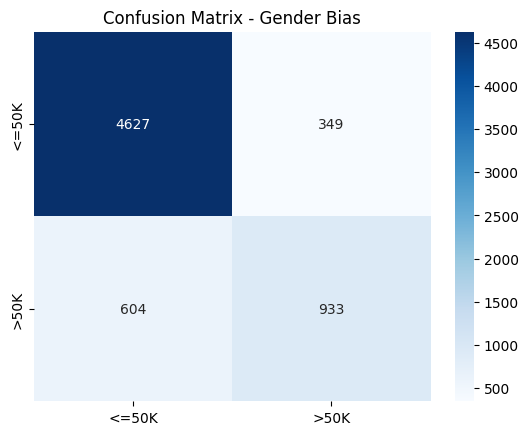

In [10]:
# Confusion Matrix Visualization
sns.heatmap(conf_matrix_gender, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title("Confusion Matrix - Gender Bias")
plt.show()


# **Apply Fairness Mitigation - Reweighing**

In [11]:
df_train_aif = X_train.copy()
df_train_aif['income'] = y_train

favorable_label = 1
unfavorable_label = 0

privileged_groups = [{'sex': 1}, {'race': 4}]
unprivileged_groups = [{'sex': 0}, {'race': 2}]

dataset_train = BinaryLabelDataset(df=df_train_aif, label_names=['income'], protected_attribute_names=['sex', 'race'],
                                   favorable_label=favorable_label, unfavorable_label=unfavorable_label)

reweighter = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
reweighed_dataset_train = reweighter.fit_transform(dataset_train)

model.fit(reweighed_dataset_train.features, reweighed_dataset_train.labels.ravel(),
          sample_weight=reweighed_dataset_train.instance_weights)

y_pred_reweighted = model.predict(X_test)

print("Accuracy after Reweighing:", accuracy_score(y_test, y_pred_reweighted))


Accuracy after Reweighing: 0.8541378780899739


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


# **Fairness Evaluation Metrics**

In [12]:
df_test_aif = X_test.copy()
df_test_aif['income'] = y_test
dataset_test = BinaryLabelDataset(df=df_test_aif, label_names=['income'], protected_attribute_names=['sex', 'race'],
                                  favorable_label=favorable_label, unfavorable_label=unfavorable_label)

df_pred_orig = X_test.copy()
df_pred_orig['income'] = y_pred.astype(int)
dataset_pred_orig = BinaryLabelDataset(df=df_pred_orig, label_names=['income'], protected_attribute_names=['sex', 'race'],
                                       favorable_label=favorable_label, unfavorable_label=unfavorable_label)

df_pred_reweighted = X_test.copy()
df_pred_reweighted['income'] = y_pred_reweighted.astype(int)
dataset_pred_reweighted = BinaryLabelDataset(df=df_pred_reweighted, label_names=['income'], protected_attribute_names=['sex', 'race'],
                                             favorable_label=favorable_label, unfavorable_label=unfavorable_label)

privileged_groups_sex = [{'sex': 1}]
unprivileged_groups_sex = [{'sex': 0}]

metric_orig_sex = ClassificationMetric(dataset_test,
                                   dataset_pred_orig,
                                   unprivileged_groups=unprivileged_groups_sex,
                                   privileged_groups=privileged_groups_sex)

print("\nOriginal Model Fairness Metrics (Sex):")
print(f"  Demographic Parity Difference: {metric_orig_sex.statistical_parity_difference():.4f}")
print(f"  Average Odds Difference: {metric_orig_sex.average_odds_difference():.4f}")

metric_reweighted_sex = ClassificationMetric(dataset_test,
                                         dataset_pred_reweighted,
                                         unprivileged_groups=unprivileged_groups_sex,
                                         privileged_groups=privileged_groups_sex)

print("\nReweighted Model Fairness Metrics (Sex):")
print(f"  Demographic Parity Difference after Reweighing: {metric_reweighted_sex.statistical_parity_difference():.4f}")
print(f"  Average Odds Difference after Reweighing: {metric_reweighted_sex.average_odds_difference():.4f}")

privileged_groups_race = [{'race': 4}]
unprivileged_groups_race = [{'race': 2}]

metric_orig_race = ClassificationMetric(dataset_test,
                                   dataset_pred_orig,
                                   unprivileged_groups=unprivileged_groups_race,
                                   privileged_groups=privileged_groups_race)

print("\nOriginal Model Fairness Metrics (Race):")
print(f"  Demographic Parity Difference: {metric_orig_race.statistical_parity_difference():.4f}")
print(f"  Average Odds Difference: {metric_orig_race.average_odds_difference():.4f}")

metric_reweighted_race = ClassificationMetric(dataset_test,
                                         dataset_pred_reweighted,
                                         unprivileged_groups=unprivileged_groups_race,
                                         privileged_groups=privileged_groups_race)

print("\nReweighted Model Fairness Metrics (Race):")
print(f"  Demographic Parity Difference after Reweighing: {metric_reweighted_race.statistical_parity_difference():.4f}")
print(f"  Average Odds Difference after Reweighing: {metric_reweighted_race.average_odds_difference():.4f}")



Original Model Fairness Metrics (Sex):
  Demographic Parity Difference: -0.1789
  Average Odds Difference: -0.0785

Reweighted Model Fairness Metrics (Sex):
  Demographic Parity Difference after Reweighing: -0.1756
  Average Odds Difference after Reweighing: -0.0728

Original Model Fairness Metrics (Race):
  Demographic Parity Difference: -0.1310
  Average Odds Difference: -0.0765

Reweighted Model Fairness Metrics (Race):
  Demographic Parity Difference after Reweighing: -0.1205
  Average Odds Difference after Reweighing: -0.0593


# **Evaluate and Compare Results**

In [13]:
print("Before Reweighing:")
print(classification_report(y_test, y_pred))

print("\nAfter Reweighing:")
print(classification_report(y_test, y_pred_reweighted))


Before Reweighing:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4976
           1       0.73      0.61      0.66      1537

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513


After Reweighing:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4976
           1       0.73      0.61      0.66      1537

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513

